In [13]:
DECAY_DATA = [
    # task, method, general_capability, steering_performance

    # ============================================================
    # Safety
    # ============================================================
    ("Safety", "Prefix-1",          39.041, 80.731),
    ("Safety", "Prefix-5",          36.621, 85.384),

    ("Safety", "ACT",               35.583, 81.246),
    ("Safety", "DAS",               34.742, 85.117),

    ("Safety", "Linear Decay",      35.846, 83.672),
    ("Safety", "Exponential Decay", 34.914, 84.531),

    ("Safety", "Full",              34.263, 86.216),


    # ============================================================
    # Sentiment
    # ============================================================
    ("Sentiment", "Prefix-1",          39.087, 88.214),
    ("Sentiment", "Prefix-5",          38.673, 89.862),

    ("Sentiment", "ACT",               36.041, 90.173),
    ("Sentiment", "DAS",               35.326, 90.084),

    ("Sentiment", "Linear Decay",      35.276, 90.438),
    ("Sentiment", "Exponential Decay", 34.461, 91.247),

    ("Sentiment", "Full",              34.518, 91.047),


    # ============================================================
    # Politeness
    # ============================================================
    ("Politeness", "Prefix-1",          38.947, 86.928),
    ("Politeness", "Prefix-5",          37.584, 88.716),

    ("Politeness", "ACT",               35.768, 88.941),
    ("Politeness", "DAS",               35.624, 89.217),

    ("Politeness", "Linear Decay",      35.932, 89.126),
    ("Politeness", "Exponential Decay", 35.887, 90.041),

    ("Politeness", "Full",              34.192, 89.843),


    # ============================================================
    # Boxed
    # ============================================================
    ("Boxed", "Prefix-1",          47.846, 91.614),
    ("Boxed", "Prefix-5",          45.428, 94.762),

    ("Boxed", "ACT",               45.283, 91.936),
    ("Boxed", "DAS",               44.972, 93.487),

    ("Boxed", "Linear Decay",      46.734, 92.463),
    ("Boxed", "Exponential Decay", 45.681, 93.214),

    ("Boxed", "Full",              43.174, 95.047),


    # ============================================================
    # Answer-XX
    # ============================================================
    ("Answer-XX", "Prefix-1",          45.734, 49.742),
    ("Answer-XX", "Prefix-5",          46.381, 52.486),

    ("Answer-XX", "ACT",               41.126, 50.973),
    ("Answer-XX", "DAS",               42.864, 52.746),

    ("Answer-XX", "Linear Decay",      45.847, 51.632),
    ("Answer-XX", "Exponential Decay", 44.726, 52.381),

    ("Answer-XX", "Full",              40.062, 52.173),
]

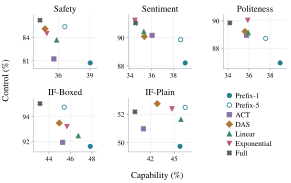

In [14]:
from pathlib import Path
import math
import shutil
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from IPython.display import SVG, display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'notebooks' / 'alpha.ipynb').is_file())
PAPER = ROOT / '6aa4d604d1c9e8e9c1117855'
TASKS = ['Safety', 'Sentiment', 'Politeness', 'Boxed', 'Answer-XX']
TITLES = ['Safety', 'Sentiment', 'Politeness', 'IF-Boxed', 'IF-Plain']
STYLES = {
    'Prefix-1': ('#237F91', 'o', 'full', 'Prefix-1'),
    'Prefix-5': ('#237F91', 'o', 'none', 'Prefix-5'),
    'ACT': ('#8771A6', 's', 'full', 'ACT'),
    'DAS': ('#AF7435', 'D', 'full', 'DAS'),
    'Linear Decay': ('#3C8966', '^', 'full', 'Linear'),
    'Exponential Decay': ('#BD596B', 'v', 'full', 'Exponential'),
    'Full': ('#505963', 'X', 'full', 'Full'),
}
expected = {(task, method) for task in TASKS for method in STYLES}
keys = [(task, method) for task, method, _, _ in DECAY_DATA]
assert len(keys) == len(set(keys)) and set(keys) == expected
assert all(math.isfinite(value) and 0 <= value <= 100
           for _, _, x, y in DECAY_DATA for value in (x, y))

RC = {'font.family': 'serif', 'font.serif': ['STIXGeneral'],
      'font.size': 8, 'axes.titlesize': 9, 'axes.labelsize': 8,
      'xtick.labelsize': 7, 'ytick.labelsize': 7,
      'axes.edgecolor': '#ADB5BD', 'axes.linewidth': .6,
      'pdf.fonttype': 42, 'ps.fonttype': 42}
with plt.rc_context(RC):
    fig, axes = plt.subplots(2, 3, figsize=(4.05, 2.55))
    fig.subplots_adjust(left=.115, right=.985, bottom=.17, top=.92,
                        wspace=.50, hspace=.55)
    TASK_AXES = {}
    for ax, task, title in zip(axes.flat, TASKS, TITLES):
        TASK_AXES[task] = ax
        rows = [row for row in DECAY_DATA if row[0] == task]
        for _, method, x, y in rows:
            color, marker, fill, _ = STYLES[method]
            ax.plot(x, y, linestyle='none', marker=marker, color=color,
                    fillstyle=fill, markersize=4.3, markeredgewidth=.8,
                    zorder=4 if method.startswith('Prefix') else 3)
        xs, ys = [r[2] for r in rows], [r[3] for r in rows]
        for setter, values in ((ax.set_xlim, xs), (ax.set_ylim, ys)):
            pad = .13 * (max(values) - min(values))
            setter(min(values) - pad, max(values) + pad)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3, integer=True))
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(color='#E6EAED', linewidth=.5)
        ax.set_axisbelow(True)
        ax.tick_params(length=2, pad=2, color='#ADB5BD')
        ax.set_title(title, pad=3)
    axes.flat[5].axis('off')
    handles = [Line2D([], [], linestyle='none', marker=marker, color=color,
                      fillstyle=fill, markersize=4.5, markeredgewidth=.8,
                      label=label)
               for color, marker, fill, label in STYLES.values()]
    axes.flat[5].legend(handles=handles, loc='center left', frameon=False,
                        fontsize=7.5, handletextpad=.4, handlelength=.8,
                        borderaxespad=0, labelspacing=.28)
    fig.supxlabel('Capability (%)', x=.54, y=.015, fontsize=9)
    fig.supylabel('Control (%)', x=.005, y=.56, fontsize=9)
    OUTPUT_PDF = ROOT / 'figs' / 'alpha_policies.pdf'
    fig.savefig(OUTPUT_PDF)
    shutil.copy2(OUTPUT_PDF, PAPER / 'figs' / OUTPUT_PDF.name)
    fig.savefig(OUTPUT_PDF.with_suffix('.svg'))
    display(SVG(filename=str(OUTPUT_PDF.with_suffix('.svg'))))
    plt.close(fig)
